# Predicting Fast-Growing Firms (2025)
Data Analysis 3 - Assignment 2  
Submitted by: Balint Decsi (ID: ), Zariza Chowdhury (ID: 2500086)    
Deadline: 15 February 2026

## Objective
The objective of this assignment is to build and evaluate predictive models for identifying fast-growing firms using the Bisnode firms panel data.      
The analysis focuses on probability prediction, classification under an explicit loss function, and comparison of model performance across industries.

**Reproducibility and Project Structure**

This notebook is designed to be run from within the `Assignment-2/` directory.  
All file paths are specified as relative paths to ensure reproducibility across environments.  
Raw data, cleaned data, outputs, and reports follow a structured folder layout consistent with prior assignments.

## Data Preparation and Sample Design

This notebook prepares the firm-level panel data for modeling.  
The workflow follows the seminar data pipeline, with targeted adaptations for the fast-growth prediction task.

The sections in this notebook are:

1) Set up the environment, imports, and project directory structure  
2) Load the raw Bisnode panel data and restrict the analysis window to 2010–2015  
3) Complete the firm–year panel and construct core status and sales-based variables  
4) Choose the target horizon (2013 vs 2012) and define the eligible baseline sample  
5) Engineer firm characteristics, financial ratios, flags, and transformed features  
6) Construct the fast-growth target and assemble the modeling dataset  
7) Perform exploratory data analysis and diagnostic checks  
8) Save the final cleaned dataset for all subsequent modeling and evaluation

### Step 1: Environment setup and imports

This step loads the required Python libraries and sets global options used throughout the notebook.

In [230]:
# Import Libraries
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [231]:
# Define project directories
base_dir = os.getcwd()

data_raw = os.path.join(base_dir, "Data", "Raw")
data_clean = os.path.join(base_dir, "Data", "Cleaned")

output_plots = os.path.join(base_dir, "Output", "Plots")
output_tables = os.path.join(base_dir, "Output", "Tables")

# Create output directories if they do not exist
for path in [data_clean, output_plots, output_tables]:
    os.makedirs(path, exist_ok=True)

# Display paths for sanity check
data_raw, data_clean, output_plots, output_tables

('/Users/zarizachowdhury/Documents/Data-Analysis-3/Assignment-2/Data/Raw',
 '/Users/zarizachowdhury/Documents/Data-Analysis-3/Assignment-2/Data/Cleaned',
 '/Users/zarizachowdhury/Documents/Data-Analysis-3/Assignment-2/Output/Plots',
 '/Users/zarizachowdhury/Documents/Data-Analysis-3/Assignment-2/Output/Tables')

### Step 2: Load the Dataset
Load the Raw Bisnode Panel Dataset

In [232]:
# Load raw data
csv_path = os.path.join(data_raw, "cs_bisnode_panel.csv")
data = pd.read_csv(csv_path)

#data = pd.read_csv("https://osf.io/download/3qyut/") # alternative way to load data

data.shape

(287829, 48)

Drop Variables with Many Missing Values

In [233]:
# drop variables with many NAs
data = data.drop(
    columns=["COGS", "finished_prod", "net_dom_sales", "net_exp_sales", "wages"],
    errors="ignore"
)

Restrict the Dataset Date Range

In [234]:
# restrict the panel window
data = data.query("year >= 2010 and year <= 2015").copy()

data.shape

(167606, 43)

### Step 3: Label Engineering

Panel Completion & Growth-Ready Features

Fill in missing firm-year combinations to create a complete panel structure.

In [235]:
# Add all missing (year, comp_id) combinations
# Missing combinations will have NaNs in all other columns
data = (
    data.set_index(["year", "comp_id"])
    .unstack(fill_value="toReplace")
    .stack()
    .reset_index()
)
data = data.replace("toReplace", np.nan)

Create an “alive” indicator and inspect core variables

In [236]:
# A firm-year is considered alive if sales are observed and positive
data["status_alive"] = ((data["sales"] > 0) & (~data["sales"].isna())).astype(int)

# Basic sanity checks
print("status_alive summary:\n", data["status_alive"].describe(), "\n")
print("sales summary:\n", data["sales"].describe())

status_alive summary:
 count    236250.000000
mean          0.571335
std           0.494886
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: status_alive, dtype: float64 

sales summary:
 count    1.638640e+05
mean     4.662059e+05
std      3.789100e+06
min     -2.553889e+05
25%      3.092593e+03
50%      2.697037e+04
75%      1.060620e+05
max      1.110294e+08
Name: sales, dtype: float64


Clean sales and construct scaled and log-transformed sales features

In [237]:
# Replace negative sales to keep logs defined
data["sales"] = np.where(data["sales"] < 0, 1, data["sales"])

# Sales features
data = data.assign(
    ln_sales=np.where(
        data["sales"] > 0,
        np.log(data["sales"]),
        np.where(data["sales"].isna(), np.nan, 0),
    ),
    sales_mil=data["sales"] / 1_000_000,
    sales_mil_log=np.where(
        data["sales"] > 0,
        np.log(data["sales"] / 1_000_000),
        np.where(data["sales"].isna(), np.nan, 0),
    ),
)

Compute within-firm year-over-year change in log sales

In [238]:
# Ensure correct panel ordering
data = data.sort_values(["comp_id", "year"])

# YoY change in log sales (growth feature)
data["d1_sales_mil_log"] = (
    data["sales_mil_log"]
    - data.groupby("comp_id")["sales_mil_log"].shift(1)
)

Create “new firm” indicators and adjust growth measures

In [239]:
# Firm age (clip negative values to zero)
data["age"] = np.where(
    data["year"] - data["founded_year"] < 0,
    0,
    data["year"] - data["founded_year"]
)

# New firm indicator: young firms or partial-year balance sheets
data["new"] = np.where(
    ((data["age"] <= 1) | (data["balsheet_notfullyear"] == 1)),
    1,
    np.where(data["age"].isna(), np.nan, 0),
)

# For new firms, set growth change to zero
data["d1_sales_mil_log"] = np.where(
    data["new"] == 1,
    0,
    np.where(data["new"].isna(), np.nan, data["d1_sales_mil_log"]),
)

# Handle remaining missing growth values
data["new"] = np.where(data["d1_sales_mil_log"].isna(), 1, data["new"])
data["d1_sales_mil_log"] = np.where(
    data["d1_sales_mil_log"].isna(), 0, data["d1_sales_mil_log"]
)

# Inspect new firm indicator
data["new"].describe()

count    236250.000000
mean          0.563319
std           0.495976
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: new, dtype: float64

### Step 4: Target Horizon Choice and Sample Design

For the fast-growth target, I use a **one-year growth window (2013 vs 2012)**.      
This choice balances signal and sample size while keeping the definition simple and interpretable.

Define an eligible baseline sample in 2012 and keep the full panel for those firms.

In [240]:
BASELINE_YEAR = 2012
OUTCOME_YEAR = 2013  # one-year growth: 2013 vs 2012

# Baseline eligibility in 2012
eligible = data.query(
    "year == @BASELINE_YEAR and status_alive == 1 and sales_mil >= 0.001 and sales_mil <= 10"
)[["comp_id"]].drop_duplicates()

# Keep all years (2010–2015 already filtered earlier) for eligible firms
data = data.merge(eligible, on="comp_id", how="inner")

data.shape

(130338, 50)

Require observed sales in both the baseline year (2012) and outcome year (2013) to support target construction.

In [241]:
# Require sales observed and > 0 in baseline and outcome years
has_sales = (
    data.query("year in [@BASELINE_YEAR, @OUTCOME_YEAR]")
    .assign(has_sales=lambda df: (df["sales"].notna()) & (df["sales"] > 0))
    .pivot_table(index="comp_id", columns="year", values="has_sales", aggfunc="max")
)

keep_ids = has_sales.loc[(has_sales[BASELINE_YEAR] == True) & (has_sales[OUTCOME_YEAR] == True)].index

data = data[data["comp_id"].isin(keep_ids)].copy()

data.shape

(114810, 50)

### Step 5: Feature Engineering

Create a small helper to overwrite saved outputs cleanly

In [242]:
# Helpers for reproducible outputs
def overwrite_csv(df, filepath, index=False):
    if os.path.exists(filepath):
        os.remove(filepath)
    df.to_csv(filepath, index=index)

def overwrite_fig(filepath):
    if os.path.exists(filepath):
        os.remove(filepath)

Recode industry categories and create firm characteristics

In [243]:
# Industry category recode
data["ind2_cat"] = data["ind2"].copy()
data["ind2_cat"] = np.where(data["ind2"] > 56, 60, data["ind2_cat"])
data["ind2_cat"] = np.where(data["ind2"] < 26, 20, data["ind2_cat"])
data["ind2_cat"] = np.where((data["ind2"] < 55) & (data["ind2"] > 35), 40, data["ind2_cat"])
data["ind2_cat"] = np.where(data["ind2"] == 31, 30, data["ind2_cat"])
data["ind2_cat"] = np.where(data["ind2"].isna(), 99, data["ind2_cat"])

# Save industry category counts
ind_tab = data.groupby("ind2_cat").count()["comp_id"].sort_values(ascending=False).reset_index()
ind_tab.columns = ["ind2_cat", "n_firm_years"]

overwrite_csv(ind_tab, os.path.join(output_tables, "industry_category_counts.csv"))

# Firm characteristics
data["age2"] = data["age"] ** 2

data["foreign_management"] = np.where(
    data["foreign"] >= 0.5, 1, np.where(data["foreign"].isna(), np.nan, 0)
)

data["gender_m"] = data["gender"].astype("category")
data["m_region_loc"] = data["region_m"].astype("category")

Construct balance sheet totals and financial ratios

In [244]:
# Balance sheet: assets cannot be negative
data["flag_asset_problem"] = np.where(
    ((data["intang_assets"] < 0) | (data["curr_assets"] < 0) | (data["fixed_assets"] < 0)),
    1,
    0,
)
data["flag_asset_problem"] = np.where(
    (data["intang_assets"].isna() | data["curr_assets"].isna() | data["fixed_assets"].isna()),
    np.nan,
    data["flag_asset_problem"],
)

asset_flag_tab = data.groupby("flag_asset_problem").count()["comp_id"].reset_index()
asset_flag_tab.columns = ["flag_asset_problem", "n_firm_years"]
overwrite_csv(asset_flag_tab, os.path.join(output_tables, "asset_problem_flag_counts.csv"))

# Fix negatives (set to 0)
data["intang_assets"] = np.where(data["intang_assets"] < 0, 0, data["intang_assets"])
data["curr_assets"] = np.where(data["curr_assets"] < 0, 0, data["curr_assets"])
data["fixed_assets"] = np.where(data["fixed_assets"] < 0, 0, data["fixed_assets"])

# Total assets
data["total_assets_bs"] = data["intang_assets"] + data["curr_assets"] + data["fixed_assets"]

# Define P/L and BS variables for ratios
pl_names = [
    "extra_exp",
    "extra_inc",
    "extra_profit_loss",
    "inc_bef_tax",
    "inventories",
    "material_exp",
    "profit_loss_year",
    "personnel_exp",
]

bs_names = [
    "intang_assets",
    "curr_liab",
    "fixed_assets",
    "liq_assets",
    "curr_assets",
    "share_eq",
    "subscribed_cap",
    "tang_assets",
]

# P/L ratios (divide by sales)
data[[col + "_pl" for col in pl_names]] = data[pl_names].div(data["sales"], axis="index")

# BS ratios (divide by total assets)
data[[col + "_bs" for col in bs_names]] = (
    data[bs_names]
    .div(data["total_assets_bs"], axis="index")
    .replace((np.inf, -np.inf), (0, 0))
)

# Keep NaN ratios where total assets are missing
for col in bs_names:
    data[col + "_bs"] = np.where(data["total_assets_bs"].isna(), np.nan, data[col + "_bs"])

Create flags and winsorize accounting tails (clipping)

In [245]:
# Winsorize tails and create flags
zero = [
    "extra_exp_pl",
    "extra_inc_pl",
    "inventories_pl",
    "material_exp_pl",
    "personnel_exp_pl",
    "curr_liab_bs",
    "fixed_assets_bs",
    "liq_assets_bs",
    "curr_assets_bs",
    "subscribed_cap_bs",
    "intang_assets_bs",
]

# Values > 1 clipped to 1 (and flagged)
data[[col + "_flag_high" for col in zero]] = np.where(
    data[zero].isna(), np.nan, (data[zero] > 1).astype(int)
)
data[zero] = np.where(data[zero].isna(), np.nan, np.where(data[zero] > 1, 1, data[zero]))

# Negative values clipped to 0 (and flagged)
data[[col + "_flag_error" for col in zero]] = np.where(
    data[zero].isna(), np.nan, (data[zero] < 0).astype(int)
)
data[zero] = np.where(data[zero].isna(), np.nan, np.where(data[zero] < 0, 0, data[zero]))

# Variables that can be negative but are mostly in [-1, 1]
anyof = ["extra_profit_loss_pl", "inc_bef_tax_pl", "profit_loss_year_pl", "share_eq_bs"]

data[[col + "_flag_low" for col in anyof]] = np.where(
    data[anyof].isna(), np.nan, (data[anyof] < -1).astype(int)
)
data[anyof] = np.where(data[anyof].isna(), np.nan, np.where(data[anyof] < -1, -1, data[anyof]))

data[[col + "_flag_high" for col in anyof]] = np.where(
    data[anyof].isna(), np.nan, (data[anyof] > 1).astype(int)
)
data[anyof] = np.where(data[anyof].isna(), np.nan, np.where(data[anyof] > 1, 1, data[anyof]))

data[[col + "_flag_zero" for col in anyof]] = np.where(
    data[anyof].isna(), np.nan, (data[anyof] == 0).astype(int)
)
data[[col + "_quad" for col in anyof]] = np.where(
    data[anyof].isna(), np.nan, data[anyof] ** 2
)

# Drop flag columns with no variation
flag_columns = [col for col in data.columns if "flag" in col]
drop_flags = data[flag_columns].std()[(data[flag_columns].std() == 0)].index
data = data.drop(columns=drop_flags)


Add CEO and labor features with simple missingness handling

In [246]:
# CEO age: clip + mean impute, add flags
data["ceo_age"] = data["year"] - data["birth_year"]

data["flag_low_ceo_age"] = (data["ceo_age"] < 25).astype(int)
data["flag_high_ceo_age"] = (data["ceo_age"] > 75).astype(int)
data["flag_miss_ceo_age"] = (data["ceo_age"].isna()).astype(int)

data["ceo_age"] = np.where(data["ceo_age"] < 25, 25, data["ceo_age"])
data["ceo_age"] = np.where(data["ceo_age"] > 75, 75, data["ceo_age"])
data["ceo_age"] = np.where(data["ceo_age"].isna(), data["ceo_age"].mean(), data["ceo_age"])
data["ceo_young"] = (data["ceo_age"] < 40).astype(int)

# Labor avg: mean impute + missing flag, keep original dropped
data["flag_miss_labor_avg"] = (data["labor_avg"].isna()).astype(int)
data["labor_avg_mod"] = np.where(data["labor_avg"].isna(), data["labor_avg"].mean(), data["labor_avg"])
data = data.drop(columns=["labor_avg"])

Shape growth-change feature and set variable types

In [247]:
# Growth feature shaping (clip YoY change)
data["d1_sales_mil_log_mod"] = np.where(
    data["d1_sales_mil_log"] < -1.5,
    -1.5,
    np.where(data["d1_sales_mil_log"] > 1.5, 1.5, data["d1_sales_mil_log"]),
)
data["d1_sales_mil_log_mod_sq"] = data["d1_sales_mil_log_mod"] ** 2

# Categorical variables
data["urban_m"] = data["urban_m"].astype("category")
data["ind2_cat"] = data["ind2_cat"].astype("category")

# Missingness flags for a few key predictors (to avoid harsh row drops)
key_vars = ["liq_assets_bs", "foreign", "material_exp_pl", "m_region_loc", "age"]

for v in key_vars:
    flag_name = f"flag_miss_{v}"
    data[flag_name] = data[v].isna().astype(int)

# Light imputations (mean for numeric, mode for category-like)
# (keeps sample size stable; models can still learn missingness via flags)
num_impute = ["liq_assets_bs", "foreign", "material_exp_pl", "age"]
for v in num_impute:
    data[v] = np.where(data[v].isna(), data[v].mean(), data[v])

# m_region_loc is categorical-like; keep as category and fill missing with "missing"
data["m_region_loc"] = data["m_region_loc"].astype("category")
data["m_region_loc"] = data["m_region_loc"].cat.add_categories(["missing"])
data["m_region_loc"] = data["m_region_loc"].fillna("missing")

# Drop unused factor levels
for col in data.select_dtypes(include=["category"]).columns:
    data[col] = data[col].cat.remove_unused_categories()

data.shape

(114810, 118)

### Step 6: Target Construction (Fast Growth, 2013 vs 2012)

Create the modeling dataset (2012 baseline + 2013 outcome)

In [248]:
# Step 6: Target construction (2013 vs 2012)
OUTCOME_YEAR = 2013  # explicit outcome year for target construction

# Baseline cross-section (2012): one row per firm
base = data.query("year == @BASELINE_YEAR").copy()
base = base.sort_values(["comp_id"]).drop_duplicates(subset=["comp_id"]).copy()

# Outcome sales in 2013 (for growth calculation)
outcome = (
    data.query("year == @OUTCOME_YEAR")[["comp_id", "sales_mil_log", "sales_mil", "sales"]]
    .rename(columns={
        "sales_mil_log": "sales_mil_log_2013",
        "sales_mil": "sales_mil_2013",
        "sales": "sales_2013",
    })
    .copy()
)

# Merge outcome onto baseline
df_model = base.merge(outcome, on="comp_id", how="inner")

df_model.shape

(19135, 121)

Compute growth and define the fast-growth label

In [249]:
# Growth metric (log growth)
df_model["growth_log_2013_2012"] = df_model["sales_mil_log_2013"] - df_model["sales_mil_log"]

# Drop missing growth values (should be minimal given sample design)
df_model = df_model.dropna(subset=["growth_log_2013_2012"]).copy()

# Fast-growth definition (top 10% of log growth)
FAST_GROWTH_Q = 0.90
growth_threshold = df_model["growth_log_2013_2012"].quantile(FAST_GROWTH_Q)

df_model["fast_growth"] = (df_model["growth_log_2013_2012"] >= growth_threshold).astype(int)

# Quick check
df_model["fast_growth"].value_counts(normalize=True)

fast_growth
0    0.899974
1    0.100026
Name: proportion, dtype: float64

Save target summary tables

In [250]:
# Save: target definition summary
target_summary = pd.DataFrame({
    "target_name": ["fast_growth"],
    "baseline_year": [BASELINE_YEAR],
    "outcome_year": [OUTCOME_YEAR],
    "growth_metric": ["log(sales_mil) difference"],
    "definition": [f"Top {int((1-FAST_GROWTH_Q)*100)}% by growth_log_2013_2012"],
    "quantile_cutoff": [FAST_GROWTH_Q],
    "threshold_value": [growth_threshold],
    "n_firms": [df_model.shape[0]],
    "fast_growth_rate": [df_model["fast_growth"].mean()],
})

overwrite_csv(target_summary, os.path.join(output_tables, "target_definition_summary.csv"))
target_summary

,target_name,baseline_year,outcome_year,growth_metric,definition,quantile_cutoff,threshold_value,n_firms,fast_growth_rate
0,fast_growth,2012,2013,log(sales_mil) difference,Top 9% by growth_log_2013_2012,0.9,0.75503,19135,0.100026


In [251]:
# Save: growth distribution summary stats
growth_stats = df_model["growth_log_2013_2012"].describe().to_frame().reset_index()
growth_stats.columns = ["stat", "value"]

overwrite_csv(growth_stats, os.path.join(output_tables, "growth_log_2013_2012_summary.csv"))
growth_stats

,stat,value
0,count,19135.000000
1,mean,-0.003175
2,std,0.945787
3,min,-10.930657
4,25%,-0.222545
5,50%,0.031262
6,75%,0.278843
7,max,8.326700


### Step 7: Exploratory Data Analysis (EDA)

This step explores the distribution of the fast-growth target and its relationship with key firm characteristics.       
The goal is diagnostic:
- sanity-check the target,
- inspect non-linear patterns, and 
- inform modeling choices.

##### 7.1 Distribution of firm growth (2013 vs 2012)

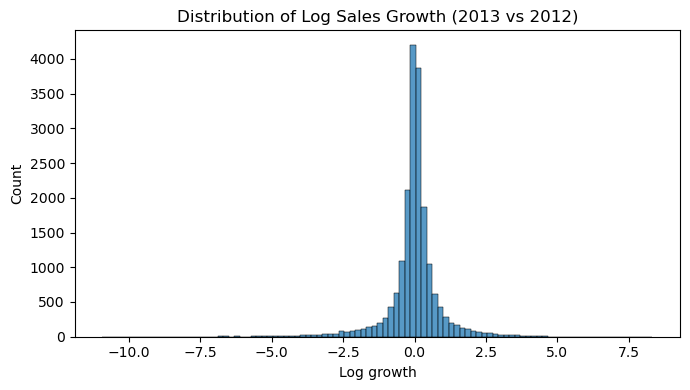

In [252]:
# Growth distribution (raw)
fig_path = os.path.join(output_plots, "growth_log_distribution.png")
overwrite_fig(fig_path)

plt.figure(figsize=(7, 4))
sns.histplot(df_model["growth_log_2013_2012"], bins=100, kde=False)
plt.title("Distribution of Log Sales Growth (2013 vs 2012)")
plt.xlabel("Log growth")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(fig_path)
plt.show()

**Interpretation**  
Sales growth is centered around zero with heavy tails, indicating mostly modest changes and a small share of extreme growers, which supports a quantile-based fast-growth definition.

##### 7.2 Fast-growth label sanity check

In [253]:
# Fast-growth share
fast_growth_tab = (
    df_model["fast_growth"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
)
fast_growth_tab.columns = ["fast_growth", "share"]

overwrite_csv(
    fast_growth_tab,
    os.path.join(output_tables, "fast_growth_share.csv")
)

fast_growth_tab

,fast_growth,share
0,0,0.899974
1,1,0.100026


**Interpretation**  
The fast-growth label captures roughly 10% of firms, confirming the intended class balance and providing a suitable setup for probabilistic classification.

##### 7.3 Growth vs Firm Size (Baseline Sales)

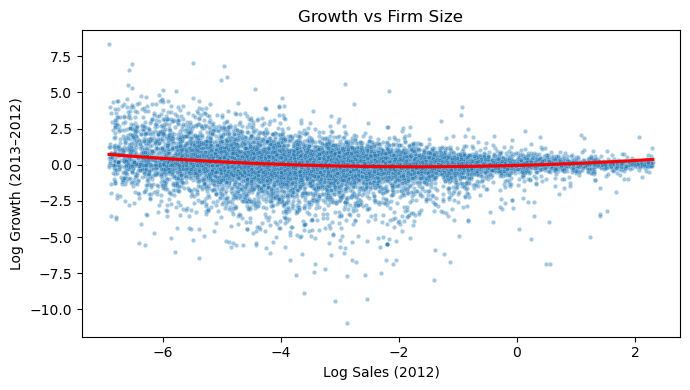

In [254]:
# Growth vs baseline size
fig_path = os.path.join(output_plots, "growth_vs_size_2012.png")
overwrite_fig(fig_path)

plt.figure(figsize=(7, 4))
sns.scatterplot(
    x="sales_mil_log",
    y="growth_log_2013_2012",
    data=df_model,
    s=10,
    alpha=0.4
)
sns.regplot(
    x="sales_mil_log",
    y="growth_log_2013_2012",
    data=df_model,
    scatter=False,
    order=2,
    ci=None,
    color="red"
)
plt.xlabel("Log Sales (2012)")
plt.ylabel("Log Growth (2013–2012)")
plt.title("Growth vs Firm Size")
plt.tight_layout()
plt.savefig(fig_path)
plt.show()

**Interpretation**  
Smaller firms tend to exhibit higher growth rates, with a clear non-linear relationship between baseline size and subsequent growth, motivating flexible model specifications.

##### 7.4 Growth vs Age (Baseline Age)

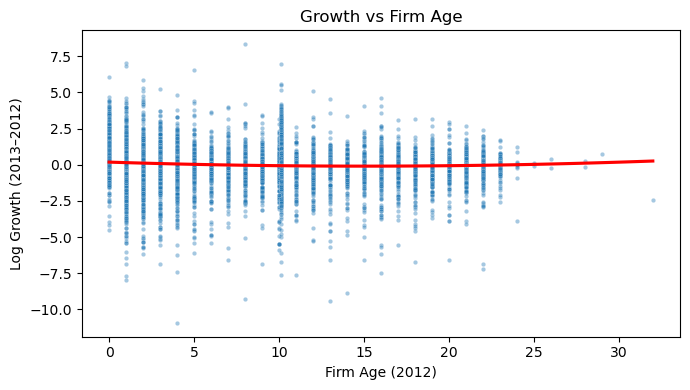

In [255]:
# Growth vs age
fig_path = os.path.join(output_plots, "growth_vs_age.png")
overwrite_fig(fig_path)

plt.figure(figsize=(7, 4))
sns.scatterplot(
    x="age",
    y="growth_log_2013_2012",
    data=df_model,
    s=10,
    alpha=0.4
)

sns.regplot(
    x="age",
    y="growth_log_2013_2012",
    data=df_model,
    scatter=False,
    order=2,
    ci=None,
    color="red"
)

plt.xlabel("Firm Age (2012)")
plt.ylabel("Log Growth (2013–2012)")
plt.title("Growth vs Firm Age")
plt.tight_layout()
plt.savefig(fig_path)
plt.show()

**Interpretation**  
Younger firms are more likely to experience higher growth, while growth rates flatten and become more stable as firms mature.

##### 7.5 Fast Growth by Industry (descriptive)

In [256]:
# Fast growth rates by industry
industry_growth = (
    df_model
    .groupby("ind2_cat")["fast_growth"]
    .agg(
        fast_growth_rate="mean",
        n_firms="count"
    )
    .reset_index()
    .sort_values("fast_growth_rate", ascending=False)
)

overwrite_csv(
    industry_growth,
    os.path.join(output_tables, "fast_growth_by_industry.csv")
)

industry_growth

,ind2_cat,fast_growth_rate,n_firms
0,20.0,0.140000,50
5,30.0,0.132075,159
11,60.0,0.125581,215
4,29.0,0.123552,259
7,33.0,0.106769,1817
10,56.0,0.104202,10758
9,55.0,0.102835,2081
1,26.0,0.088119,1010
8,40.0,0.087179,195
3,28.0,0.078176,1842


**Interpretation**  
Fast-growth rates vary across industries, suggesting sector-specific dynamics and supporting the inclusion of industry controls in the prediction models.

##### 7.6 Logit Regression

As a final diagnostic, I estimate a simple logit model to examine how firm size and age relate to the probability of fast growth, without aiming for prediction performance.

In [257]:
import statsmodels.formula.api as smf

# Diagnostic logit regression
logit_diag = smf.logit(
    "fast_growth ~ sales_mil_log + age + d1_sales_mil_log",
    data=df_model
).fit(disp=False)

# Extract results into a tidy table
logit_table = (
    logit_diag
    .summary2()
    .tables[1]
    .reset_index()
    .rename(columns={"index": "variable"})
)

# Save regression table
overwrite_csv(
    logit_table,
    os.path.join(output_tables, "diagnostic_logit_fast_growth.csv")
)

logit_table

,variable,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
0,Intercept,-3.823616,0.086024,-44.448432,0.000000e+00,-3.992219,-3.655013
1,sales_mil_log,-0.618017,0.019051,-32.440718,7.322281e-231,-0.655356,-0.580679
2,age,-0.081939,0.004446,-18.431679,7.317573e-76,-0.090653,-0.073226
3,d1_sales_mil_log,-0.114633,0.025781,-4.446343,8.734438e-06,-0.165164,-0.064103


**Interpretation**  
Smaller and younger firms are significantly more likely to be fast-growing, while higher recent growth is associated with lower subsequent fast-growth probability, consistent with mean reversion.

### Step 8: Save Final Modeling Dataset

At this point, all cleaning, feature engineering, target construction, and diagnostics are complete.         
The dataset below is the final version used for all subsequent modeling and evaluation.

In [258]:
# Save final cleaned dataset for modeling
final_clean_path = os.path.join(data_clean, "bisnode_firms_clean.csv")

if os.path.exists(final_clean_path):
    os.remove(final_clean_path)

df_model.to_csv(final_clean_path, index=False)

final_clean_path

'/Users/zarizachowdhury/Documents/Data-Analysis-3/Assignment-2/Data/Cleaned/bisnode_firms_clean.csv'